# Operaciones gráficas y anotación visual

**Duración estimada:** 50 minutos

## Objetivo

En este cuaderno vas a dibujar sobre imágenes reales usando OpenCV. El foco está en aprender a ubicar coordenadas y usarlas para marcar una región, un punto o una etiqueta de forma clara.


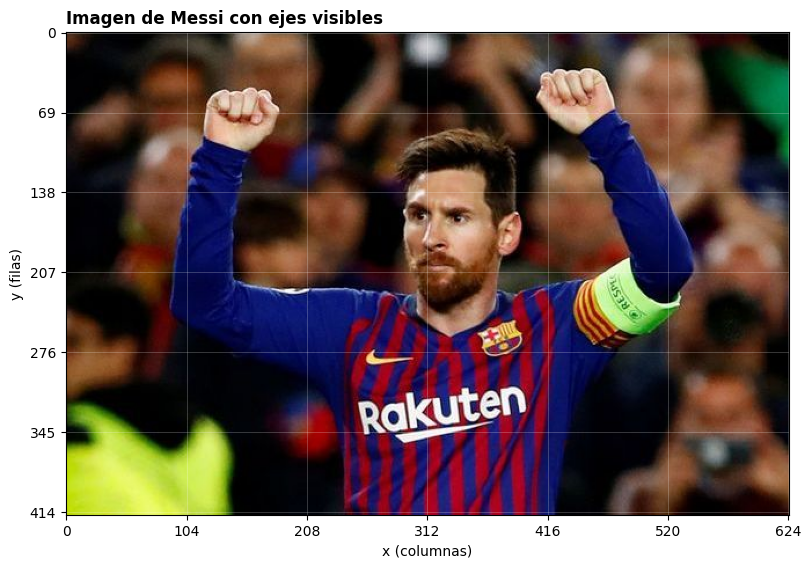

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()

imagen_messi = abrir_imagen_rgb("messi.jpg")
mostrar_una_imagen(imagen_messi, "Imagen de Messi con ejes visibles")


## 1. Anotar un rostro en una imagen real

Vamos a marcar el rostro de Messi con una caja rectangular. La idea es que puedas leer las coordenadas en la imagen y entender cómo se traducen a una región concreta.


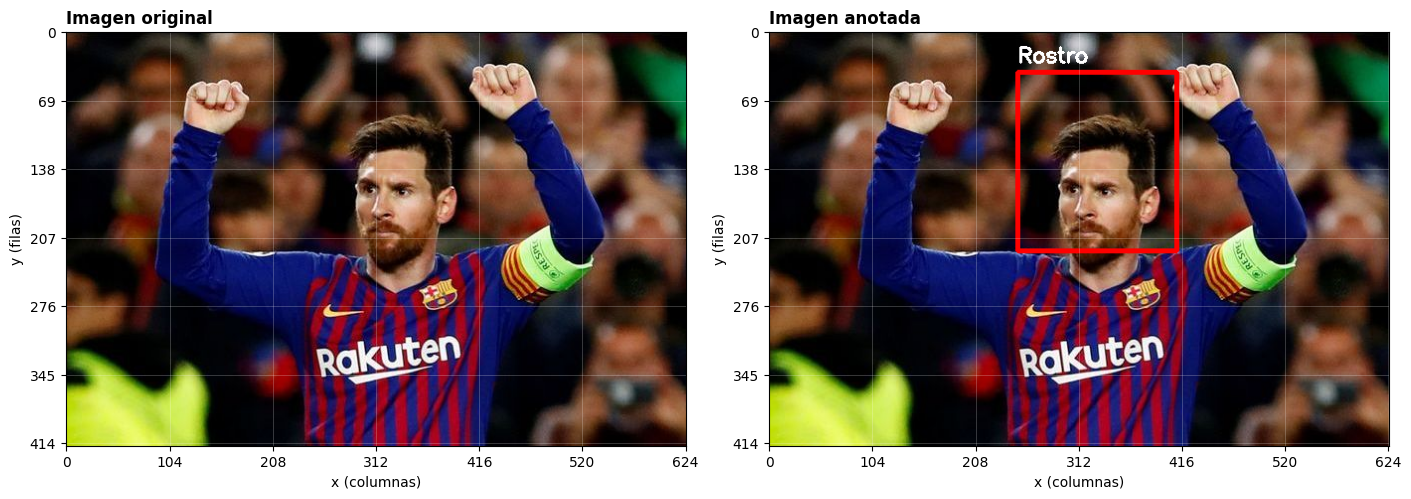

In [2]:
imagen_messi_anotada = imagen_messi.copy()

x_inicial = 250
y_inicial = 40
x_final = 410
y_final = 220

cv2.rectangle(imagen_messi_anotada, (x_inicial, y_inicial), (x_final, y_final), (255, 0, 0), 3)
cv2.putText(imagen_messi_anotada, "Rostro", (250, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

mostrar_varias_imagenes(
    [imagen_messi, imagen_messi_anotada],
    ["Imagen original", "Imagen anotada"],
    tamano=(14, 5),
)


## 2. Marcar una región útil en la imagen de globos

En la versión anterior la región elegida caía sobre el cielo y no era pedagógicamente útil. Acá corregimos eso y marcamos una zona que sí contiene un globo naranja reconocible.


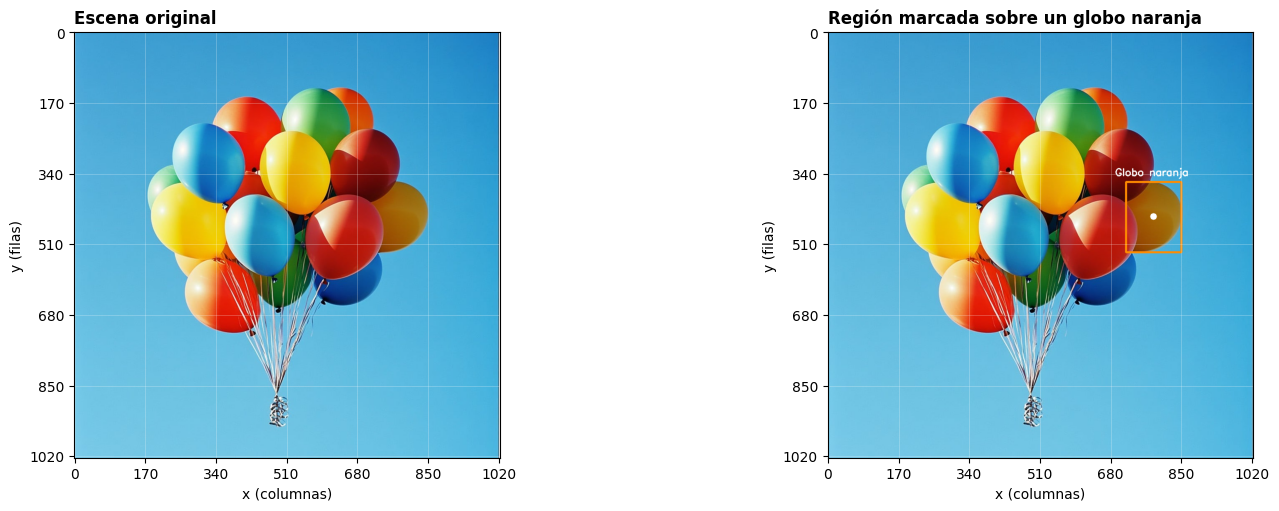

In [3]:
imagen_globos = abrir_imagen_rgb("globos.jpg")
imagen_globos_anotada = imagen_globos.copy()

# Esta región encierra uno de los globos naranjas visibles a la derecha.
x_inicial = 716
y_inicial = 360
x_final = 849
y_final = 529

cv2.rectangle(imagen_globos_anotada, (x_inicial, y_inicial), (x_final, y_final), (255, 140, 0), 4)
cv2.putText(imagen_globos_anotada, "Globo naranja", (690, 345), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
cv2.circle(imagen_globos_anotada, (782, 443), 8, (255, 255, 255), -1)

mostrar_varias_imagenes(
    [imagen_globos, imagen_globos_anotada],
    ["Escena original", "Región marcada sobre un globo naranja"],
    tamano=(15, 5),
)


## Cierre

Dibujar no es solo “decorar” una imagen. Sirve para comunicar una decisión: qué región miramos, dónde empieza y dónde termina, qué coordenadas importan y qué queremos mostrarle a otra persona.
